# Fraud Detection in Financial Transactions (End-to-End ML Project)
## Author: Nicodimus Munyuki
This notebook builds a fraud detection system using ML with EDA, feature engineering, XGBoost tuning, and SHAP explainability.

## Problem Statement
Detect fraudulent transactions in a highly imbalanced financial dataset using machine learning.

## Data Source
This project uses the **PaySim Synthetic Financial Dataset** from Kaggle.  
The data simulates mobile money transactions and is publicly available under the CC BY-SA 4.0 license.

**Dataset link:** [Synthetic Financial Datasets For Fraud Detection](https://www.kaggle.com/datasets/ealaxi/paysim1)

In [1]:
!pip install xgboost

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap
import warnings
warnings.filterwarnings('ignore')


In [3]:

# Load dataset
df = pd.read_csv("Synthetic financial fraud.csv")
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


##  Exploratory Data Analysis (EDA)

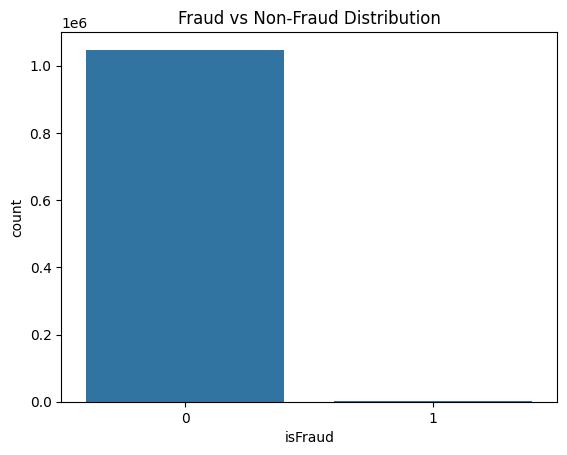

In [4]:

# Fraud distribution
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


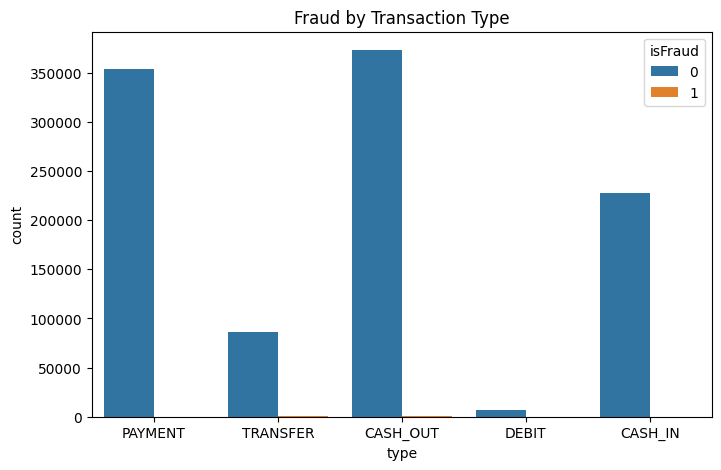

In [5]:

# Transaction type vs fraud
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', hue='isFraud')
plt.title("Fraud by Transaction Type")
plt.show()


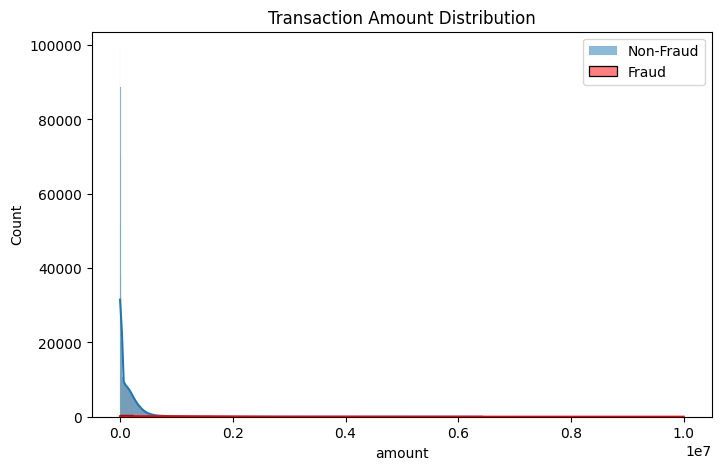

In [6]:

# Amount distribution
plt.figure(figsize=(8,5))
sns.histplot(df[df['isFraud']==0]['amount'], label='Non-Fraud', kde=True)
sns.histplot(df[df['isFraud']==1]['amount'], label='Fraud', color='red', kde=True)
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()


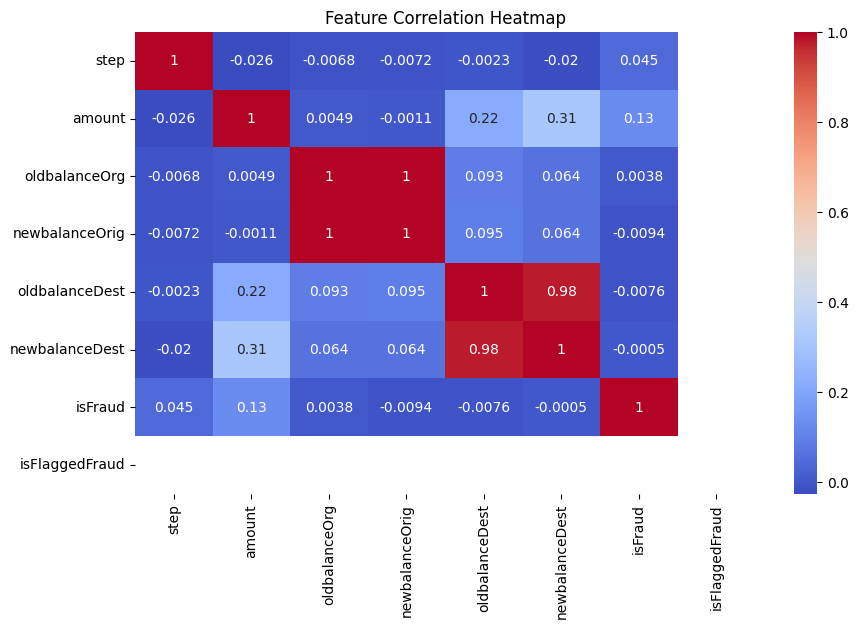

In [7]:

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


## Feature Engineering

In [8]:

df = df.copy()

# Balance error features
df['orig_balance_error'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['dest_balance_error'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

# Drop leakage-prone raw IDs
df = df.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')

# One-hot encoding
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# Final Clean
df = df.dropna()


## Train-Test Split

In [9]:

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Baseline Model (Logistic Regression)

In [10]:

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       1.00      0.96      0.98    209487
           1       0.03      0.90      0.05       228

    accuracy                           0.96    209715
   macro avg       0.51      0.93      0.52    209715
weighted avg       1.00      0.96      0.98    209715



# Random Forest Model

In [11]:

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       1.00      0.98      0.99       228

    accuracy                           1.00    209715
   macro avg       1.00      0.99      0.99    209715
weighted avg       1.00      1.00      1.00    209715



### Random Forest Performance Interpretation

The Random Forest model achieved very high precision on the fraud class. While this may appear ideal, such near-perfect performance is uncommon in real-world fraud detection scenarios.

This may indicate overfitting or sensitivity to patterns specific to the synthetic dataset, meaning the model may not generalize well to unseen data.

Therefore, despite strong performance metrics, caution is required when considering Random Forest for deployment.

# XGBoost + Hyperparameter Tuning

In [12]:

scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=8,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

pred_xgb = best_model.predict(X_test)

print("Best Params:", search.best_params_)
print(classification_report(y_test, pred_xgb))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.71      0.98      0.82       228

    accuracy                           1.00    209715
   macro avg       0.86      0.99      0.91    209715
weighted avg       1.00      1.00      1.00    209715



### Note on Accuracy

Although the model shows an accuracy close to 100%, this metric is not meaningful in this context due to extreme class imbalance.

Since fraudulent transactions represent only a small fraction of the dataset, a model can achieve high accuracy by simply predicting the majority class.

Therefore, precision, recall, and PR-AUC are more appropriate metrics for evaluating model performance in fraud detection.

PR-AUC Score: 0.9708


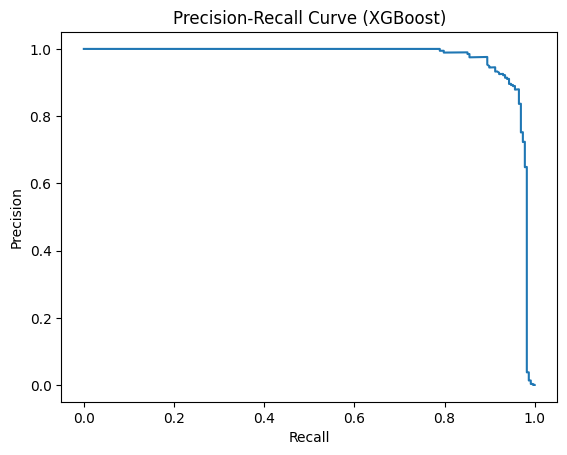

In [13]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities from XGBoost
y_scores = best_model.predict_proba(X_test)[:, 1]

# Compute precision-recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Compute PR-AUC
pr_auc = auc(recall, precision)

print(f"PR-AUC Score: {pr_auc:.4f}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.show()

### Precision-Recall Evaluation

Due to the extreme class imbalance in the dataset, PR-AUC is a more informative metric than ROC-AUC.

The Precision-Recall Curve highlights the trade-off between detecting fraudulent transactions (recall) and minimizing false alarms (precision), making it particularly suitable for fraud detection problems.

# Model Explainability (SHAP)

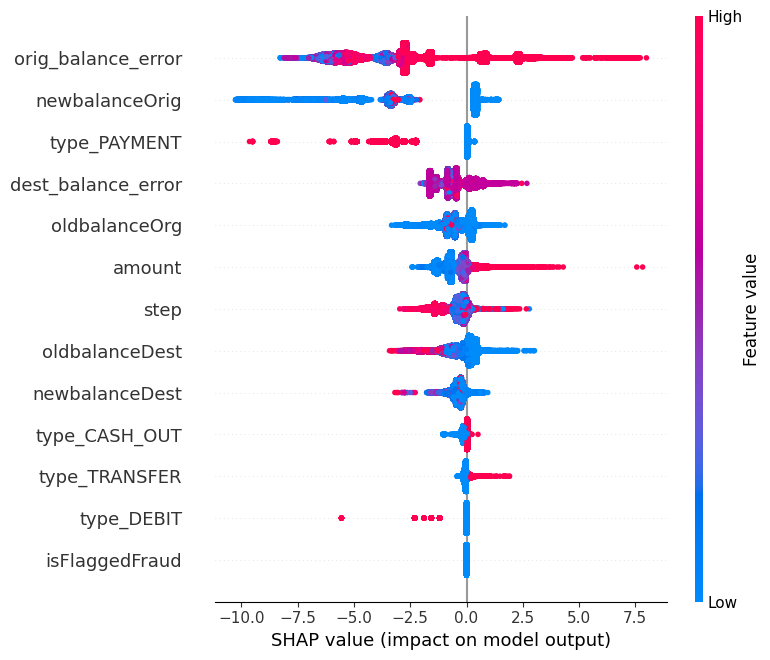

In [14]:

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


## Deployment Considerations

The trained XGBoost model can be integrated into a real-time fraud detection system.

In a production environment:

- Incoming transactions would undergo the same preprocessing and feature engineering steps
- The model would assign a fraud probability score to each transaction
- Transactions exceeding a defined threshold would be flagged or blocked for further review

The model can be deployed as a REST API using frameworks such as Flask or FastAPI, allowing real-time interaction with external systems.

For high-volume systems, the model can be integrated into streaming platforms (e.g., Kafka) to enable continuous transaction monitoring.

Additionally, monitoring mechanisms should be implemented to detect data drift and ensure the model maintains performance over time.

# Conclusion

This project demonstrates the development of a robust fraud detection system using machine learning techniques on highly imbalanced data.

Among the models evaluated, XGBoost provided the best balance between recall and precision, making it the most suitable for real-world deployment.

Feature engineering, particularly balance error metrics, played a critical role in improving model performance.

The inclusion of SHAP explainability enhances transparency, making the model suitable for regulated financial environments.

Overall, the solution is capable of detecting the majority of fraudulent transactions while maintaining a manageable level of false positives.